<a href="https://colab.research.google.com/github/Vihhycherezass/TemperatureTimeSeriesForecast-/blob/main/Model_TempTimeSeriesForecast.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

import joblib


In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("parthdande/timeseries-weather-dataset")

print("Path to dataset files:", path)

100%|██████████| 11.4M/11.4M [00:01<00:00, 6.10MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/parthdande/timeseries-weather-dataset/versions/2


In [ ]:
os.listdir(path)

['Weather_Data_1980_2024(hourly).csv', 'Weather_dataset.csv']

In [ ]:
file_path = os.path.join(path, 'Weather_Data_1980_2024(hourly).csv')

df = pd.read_csv(file_path, parse_dates=['time'])

df.head()

,time,temperature,relative_humidity,dew_point,precipitation (mm),rain (mm),snowfall (cm),pressure_msl (hPa),surface_pressure (hPa),cloud_cover (%),cloud_cover_low (%),cloud_cover_mid (%),cloud_cover_high (%),vapour_pressure_deficit (kPa),wind_speed_10m (km/h),wind_direction,is_Day
0,1980-01-01 00:00:00,12.7,83,10.0,0.0,0.0,0,1012.8,945.1,1,1,0,0,0.25,7.5,235,0
1,1980-01-01 01:00:00,12.9,82,9.9,0.0,0.0,0,1012.2,944.5,4,4,0,0,0.26,7.9,231,0
2,1980-01-01 02:00:00,13.2,82,10.2,0.0,0.0,0,1012.3,944.7,13,14,0,0,0.27,7.5,235,1
3,1980-01-01 03:00:00,15.9,78,12.0,0.0,0.0,0,1013.5,946.4,23,26,0,0,0.40,6.6,248,1
4,1980-01-01 04:00:00,19.4,67,13.1,0.0,0.0,0,1014.6,948.2,9,10,0,0,0.75,8.7,265,1


In [ ]:
df = df.sort_values('time')
df = df.set_index('time')

df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 389496 entries, 1980-01-01 00:00:00 to 2024-06-06 23:00:00
Data columns (total 16 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   temperature                    389496 non-null  float64
 1   relative_humidity              389496 non-null  int64  
 2   dew_point                      389496 non-null  float64
 3   precipitation (mm)             389496 non-null  float64
 4   rain (mm)                      389496 non-null  float64
 5   snowfall (cm)                  389496 non-null  int64  
 6   pressure_msl (hPa)             389496 non-null  float64
 7   surface_pressure (hPa)         389496 non-null  float64
 8   cloud_cover (%)                389496 non-null  int64  
 9   cloud_cover_low (%)            389496 non-null  int64  
 10  cloud_cover_mid (%)            389496 non-null  int64  
 11  cloud_cover_high (%)           389496 non-null  int64  
 

In [ ]:
df.index.is_monotonic_increasing

True

In [ ]:
df.index.to_series().diff().value_counts().head()

,count
time,
0 days 01:00:00,389495


In [ ]:
df.isna().sum()

,0
temperature,0
relative_humidity,0
dew_point,0
precipitation (mm),0
rain (mm),0
snowfall (cm),0
pressure_msl (hPa),0
surface_pressure (hPa),0
cloud_cover (%),0
cloud_cover_low (%),0


In [ ]:
df.describe()

,temperature,relative_humidity,dew_point,precipitation (mm),rain (mm),snowfall (cm),pressure_msl (hPa),surface_pressure (hPa),cloud_cover (%),cloud_cover_low (%),cloud_cover_mid (%),cloud_cover_high (%),vapour_pressure_deficit (kPa),wind_speed_10m (km/h),wind_direction,is_Day
count,389496.000000,389496.000000,389496.000000,389496.000000,389496.000000,389496.0,389496.000000,389496.000000,389496.000000,389496.000000,389496.000000,389496.000000,389496.000000,389496.000000,389496.000000,389496.000000
mean,24.130906,63.946035,15.233168,0.114465,0.114465,0.0,1010.373729,945.282515,35.152749,24.285045,16.730059,30.083403,1.285855,10.992143,204.201219,0.507191
std,4.996178,25.821642,6.103542,0.573517,0.573517,0.0,4.182607,3.720786,39.431550,35.525810,26.146271,40.570670,1.258055,5.795914,94.468096,0.499949
min,7.100000,6.000000,-11.800000,0.000000,0.000000,0.0,991.100000,927.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000
25%,21.500000,42.000000,10.200000,0.000000,0.000000,0.0,1007.300000,942.700000,0.000000,0.000000,0.000000,0.000000,0.300000,6.700000,98.000000,0.000000
50%,23.400000,67.000000,16.100000,0.000000,0.000000,0.0,1010.500000,945.600000,16.000000,0.000000,2.000000,0.000000,0.850000,9.700000,245.000000,1.000000
75%,27.000000,89.000000,21.100000,0.000000,0.000000,0.0,1013.600000,948.000000,75.000000,45.000000,24.000000,75.000000,1.940000,14.800000,270.000000,1.000000
max,41.700000,100.000000,25.400000,29.500000,29.500000,0.0,1024.100000,957.300000,100.000000,100.000000,100.000000,100.000000,7.250000,43.300000,360.000000,1.000000


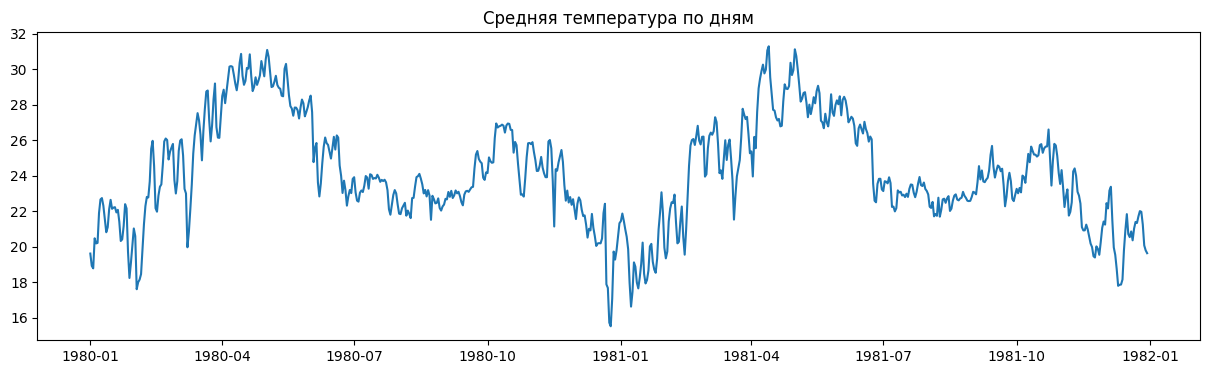

In [ ]:
daily_temp = df["temperature"].resample("D").mean()

plt.figure(figsize=(15,4))
plt.plot(daily_temp.index[:730], daily_temp.values[:730])
plt.title("Средняя температура по дням")
plt.show()

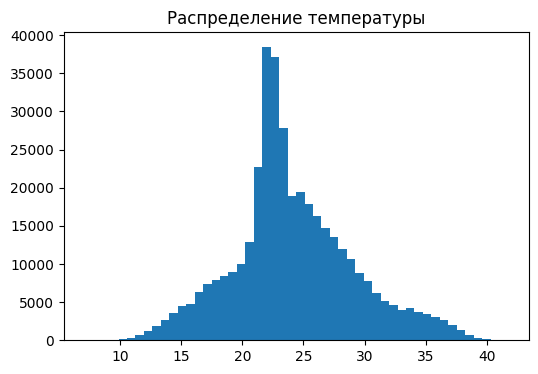

In [ ]:
plt.figure(figsize=(6,4))
plt.hist(df["temperature"], bins=50)
plt.title("Распределение температуры")
plt.show()

In [ ]:
def create_sliding_window(data, target_col_index, window_size=24):
  X = []
  y = []

  for i in range(len(data) - window_size):
    X.append(data[i:i + window_size])
    y.append(data[i + window_size, target_col_index])

  return np.array(X), np.array(y)

In [ ]:
feature_columns = df.columns.tolist()

scaler = MinMaxScaler()

scaled_data = scaler.fit_transform(df[feature_columns])

target_index = feature_columns.index('temperature')

In [ ]:
window_size = 24

X, y = create_sliding_window(scaled_data, target_index, window_size)

X.shape, y.shape

((389472, 24, 16), (389472,))

In [ ]:
train_size = int(len(X) * 0.8)

X_train = X[:train_size]
y_train = y[:train_size]

X_test = X[train_size:]
y_test = y[train_size:]

In [ ]:
model = keras.Sequential([
    layers.Input(shape=(window_size, X.shape[2])),
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(1)
])

model.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae'],
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 384)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │        24,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,705 (96.50 KB)

 Trainable params: 24,705 (96.50 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history = model.fit(
    X_train, y_train,
    epochs=5,
    batch_size=64,
    validation_split=0.1,
    verbose=1
)

Epoch 1/5
4382/4382 ━━━━━━━━━━━━━━━━━━━━ 13s 3ms/step - loss: 0.0044 - mae: 0.0350 - val_loss: 2.6431e-04 - val_mae: 0.0123
Epoch 2/5
4382/4382 ━━━━━━━━━━━━━━━━━━━━ 11s 2ms/step - loss: 3.2605e-04 - mae: 0.0139 - val_loss: 1.6536e-04 - val_mae: 0.0094
Epoch 3/5
4382/4382 ━━━━━━━━━━━━━━━━━━━━ 11s 2ms/step - loss: 2.6544e-04 - mae: 0.0125 - val_loss: 1.6154e-04 - val_mae: 0.0095
Epoch 4/5
4382/4382 ━━━━━━━━━━━━━━━━━━━━ 10s 2ms/step - loss: 2.3676e-04 - mae: 0.0117 - val_loss: 1.9423e-04 - val_mae: 0.0105
Epoch 5/5
4382/4382 ━━━━━━━━━━━━━━━━━━━━ 21s 2ms/step - loss: 1.8939e-04 - mae: 0.0104 - val_loss: 1.3921e-04 - val_mae: 0.0085


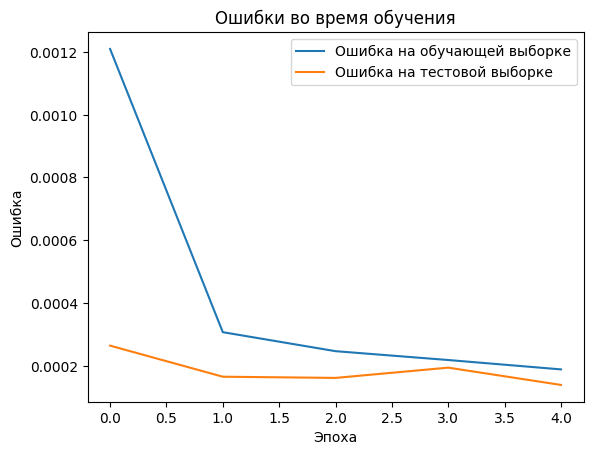

In [ ]:
plt.plot(history.history['loss'], label='Ошибка на обучающей выборке')
plt.plot(history.history['val_loss'], label='Ошибка на тестовой выборке')
plt.title('Ошибки во время обучения')
plt.xlabel('Эпоха')
plt.ylabel('Ошибка')
plt.legend()
plt.show()

In [ ]:
model.evaluate(X_test, y_test)

2435/2435 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - loss: 2.6443e-04 - mae: 0.0111


[0.00033292625448666513, 0.012536614201962948]

In [ ]:
lstm_model = keras.Sequential([
    layers.Input(shape=(window_size, X.shape[2])),
    layers.LSTM(64),
    layers.Dense(32, activation='relu'),
    layers.Dense(1)
])

lstm_model.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae'],
)

lstm_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 64)             │        20,736 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 22,849 (89.25 KB)

 Trainable params: 22,849 (89.25 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history = lstm_model.fit(
    X_train, y_train,
    epochs=5,
    batch_size=64,
    validation_split=0.1,
    verbose=1,
)

Epoch 1/5
4382/4382 ━━━━━━━━━━━━━━━━━━━━ 26s 5ms/step - loss: 0.0022 - mae: 0.0233 - val_loss: 1.8130e-04 - val_mae: 0.0102
Epoch 2/5
4382/4382 ━━━━━━━━━━━━━━━━━━━━ 24s 6ms/step - loss: 1.6654e-04 - mae: 0.0093 - val_loss: 1.2921e-04 - val_mae: 0.0082
Epoch 3/5
4382/4382 ━━━━━━━━━━━━━━━━━━━━ 24s 5ms/step - loss: 1.2936e-04 - mae: 0.0081 - val_loss: 1.1153e-04 - val_mae: 0.0074
Epoch 4/5
4382/4382 ━━━━━━━━━━━━━━━━━━━━ 24s 5ms/step - loss: 1.1558e-04 - mae: 0.0075 - val_loss: 1.0673e-04 - val_mae: 0.0073
Epoch 5/5
4382/4382 ━━━━━━━━━━━━━━━━━━━━ 24s 5ms/step - loss: 1.0885e-04 - mae: 0.0072 - val_loss: 1.0864e-04 - val_mae: 0.0069


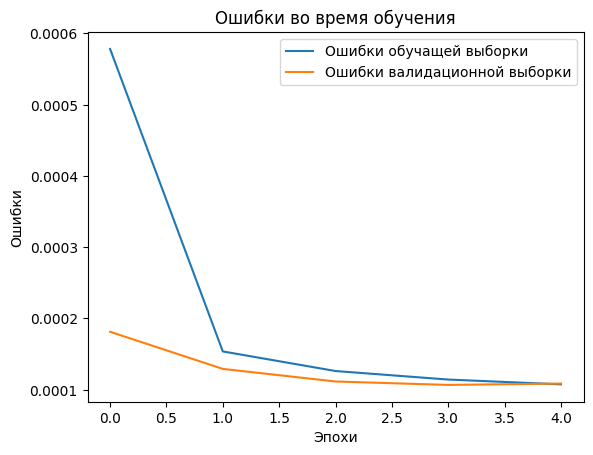

In [ ]:
plt.plot(history.history['loss'], label='Ошибки обучащей выборки')
plt.plot(history.history['val_loss'], label='Ошибки валидационной выборки')
plt.title("Ошибки во время обучения")
plt.xlabel('Эпохи')
plt.ylabel('Ошибки')
plt.legend()
plt.show()

In [ ]:
lstm_model.evaluate(X_test, y_test)

2435/2435 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - loss: 2.7673e-04 - mae: 0.0102


[0.00035422234213910997, 0.011788246221840382]

In [ ]:
temp_min = df['temperature'].min()
temp_max = df['temperature'].max()

mae_celsius = 0.011788246221840382 * (temp_max - temp_min)
mae_celsius

0.4078733192756772

In [ ]:
from google.colab import drive

drive.mount('/content/drive')

model_path = '/content/drive/MyDrive/lstm_temperature_model.keras'
scaler_path = '/content/drive/MyDrive/scaler.save'
window_params_path = '/content/drive/MyDrive/window_params.save'

lstm_model.save(model_path)
joblib.dump(scaler, scaler_path)
window_params = {
    "window_size": window_size,
    "feature_columns": feature_columns,
    "target_index": target_index
}
joblib.dump(window_params, window_params_path)

Mounted at /content/drive


['/content/drive/MyDrive/window_params.save']